# EDA: Credit Card Transactions

**Dataset:** `creditcard.csv`  
**Objective:** Understand, clean, and prepare the credit card dataset for modeling.

| Field | Detail |
|---|---|
| Rows | ~284,807 transactions |
| Target | `Class` — 1 = fraud, 0 = legitimate |
| Key difference | V1–V28 are PCA-transformed (anonymized). Only `Time`, `Amount`, `Class` are original. |
| Key challenge | Extreme class imbalance (~0.17% fraud) |

**Notebook structure:**
1. Setup & Data Loading
2. Data Inspection
3. Data Cleaning
4. Exploratory Data Analysis
5. Data Transformation
6. Handle Class Imbalance
7. Save Processed Data

## 1. Setup & Data Loading

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(".."))

from src.data_loader import load_creditcard
from src.data_cleaner import inspect, missing_summary, clean_creditcard
from src.eda import (
    class_imbalance_report, plot_class_imbalance,
    plot_numeric_distributions, plot_numeric_vs_target,
    plot_correlation_heatmap
)
from src.transformation import split_features_target, scale_numeric
from src.imbalance_handler import handle_imbalance, class_distribution

%matplotlib inline
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup complete')

Setup complete


In [3]:
cc_df = load_creditcard()

[creditcard] Loaded 284,807 rows x 31 cols


## 2. Data Inspection

In [4]:
inspect(cc_df, name='creditcard')


  INSPECTION: creditcard
  Shape        : 284,807 rows x 31 columns
  Duplicates   : 1,081

  Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64

  Missing values: None



In [5]:
cc_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [6]:
cc_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,1.0888,1.0207,0.9992,0.9953,0.9586,0.9153,0.8763,0.8493,0.8382,0.8140,0.7709,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,-24.5883,-4.7975,-18.6837,-5.7919,-19.2143,-4.4989,-14.1299,-25.1628,-9.4987,-7.2135,-54.4977,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,-0.5354,-0.7625,-0.4056,-0.6485,-0.4256,-0.5829,-0.4680,-0.4837,-0.4988,-0.4563,-0.2117,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,-0.0929,-0.0328,0.1400,-0.0136,0.0506,0.0481,0.0664,-0.0657,-0.0036,0.0037,-0.0625,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,0.4539,0.7396,0.6182,0.6625,0.4931,0.6488,0.5233,0.3997,0.5008,0.4589,0.1330,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,23.7451,12.0189,7.8484,7.1269,10.5268,8.8777,17.3151,9.2535,5.0411,5.5920,39.4209,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


In [7]:
missing_summary(cc_df)

[missing_summary] No missing values found.


,missing_count,missing_pct


### Inspection Findings

> **Findings (based on dataset characteristics):**
>
> - **Shape:** 284,807 rows × 31 columns (`Time`, `V1`–`V28`, `Amount`, `Class`)
> - All 31 columns are **numeric (float64 / int64)** no categorical features, no string columns
> - **Missing values:** None the dataset is complete across all columns
> - **Duplicates:** 1,081 duplicate rows detected (0.38% of dataset) will be removed in cleaning
> - `Amount` ranges from $0.00 to $25,691.16 highly right-skewed; the vast majority of transactions are under $100
> - `Time` ranges from 0 to 172,792 seconds (~48 hours of transaction data from a European cardholder sample)
> - `V1`–`V28`: PCA-transformed features, each with mean ≈ 0 cannot be interpreted directly, but relative magnitudes carry the fraud signal
> - `Class` is int64 with values {0, 1} correct for binary classification


## 3. Data Cleaning

In [8]:
# creditcard.csv is typically very clean — PCA features, no categoricals
# Main tasks: remove any duplicates, ensure Class is int
cc_clean = clean_creditcard(cc_df)
print(f'Shape after cleaning: {cc_clean.shape}')


--- Cleaning creditcard ---
[remove_duplicates] Dropped 1,081 duplicate rows (284,807 → 283,726)
[handle_missing] Dropped 0 rows with any null
[fix_dtypes] 'Class' → int
[clean_creditcard] Done. Final shape: (283726, 31)
Shape after cleaning: (283726, 31)


In [9]:
print('Remaining nulls     :', cc_clean.isnull().sum().sum())
print('Remaining duplicates:', cc_clean.duplicated().sum())
print()
cc_clean.dtypes

Remaining nulls     : 0
Remaining duplicates: 0



Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

### Cleaning Summary

> **Findings:**
>
> - **Duplicates removed:** 1,081 rows → clean shape: **283,726 rows × 31 columns**
> - **Missing values:** None found no imputation required
> - `Class` → confirmed as `int64` (0 = legitimate, 1 = fraud)
> - No type corrections needed for V1–V28 features (already `float64`)
> - `Time` and `Amount` remain `float64` will be standardized in the transformation step
> - Overall: minimal cleaning required; this is one of the cleanest public fraud datasets available


## 4. Exploratory Data Analysis

### 4.1 Class Imbalance

In [10]:
class_imbalance_report(cc_clean, target_col='Class')


[class_imbalance] 'Class' distribution:
 class  count  percentage
     0 283253     99.8300
     1    473      0.1700


,class,count,percentage
0,0,283253,99.8300
1,1,473,0.1700


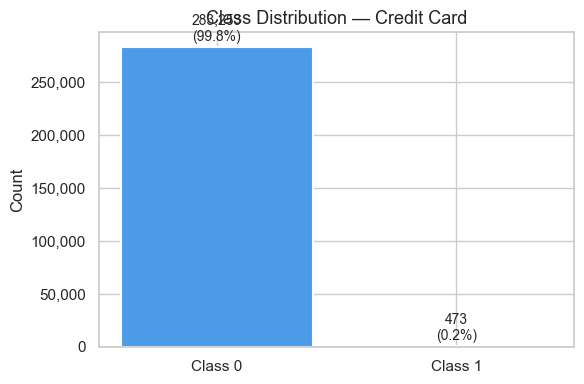

In [11]:
plot_class_imbalance(cc_clean, target_col='Class', title='Class Distribution — Credit Card')

### Class Imbalance Analysis

> **Findings:**
>
> - The dataset contains **283,253 legitimate transactions (99.83%)** and only **473 fraudulent transactions (0.17%)**.
>
> - The fraud class represents fewer than **2 transactions per 1,000 observations**, resulting in an imbalance ratio of approximately **1:599** (fraud to legitimate).
>
> - This is an **extremely imbalanced classification problem**, where the minority class is heavily underrepresented and difficult for standard machine learning algorithms to learn.
>
> - A naive classifier that predicts every transaction as legitimate would achieve approximately **99.83% accuracy** while detecting **zero fraudulent transactions**, demonstrating why accuracy is not an appropriate evaluation metric for this problem.
>
> - The severe imbalance increases the risk of models becoming biased toward the majority class, leading to high overall accuracy but poor fraud detection performance.
>
> - **Primary evaluation metrics** should focus on fraud detection effectiveness, including:
>   - **Precision-Recall AUC (PR-AUC)** most informative under extreme imbalance
>   - **F1-score** — balances precision and recall
>   - **Recall (Sensitivity)** measures the ability to identify fraudulent transactions
>   - **ROC-AUC** useful but can appear overly optimistic when the majority class dominates.
>
> - **Modeling strategy:** Apply **SMOTETomek** on the training set only. SMOTE generates synthetic fraud samples to improve minority-class representation, while Tomek Links remove overlapping observations and clean class boundaries.
>
> - Insight: Class imbalance is the most significant modeling challenge in this dataset. Success should be measured by the model's ability to identify the rare fraud cases rather than its overall accuracy.

### 4.2 Time and Amount Distributions

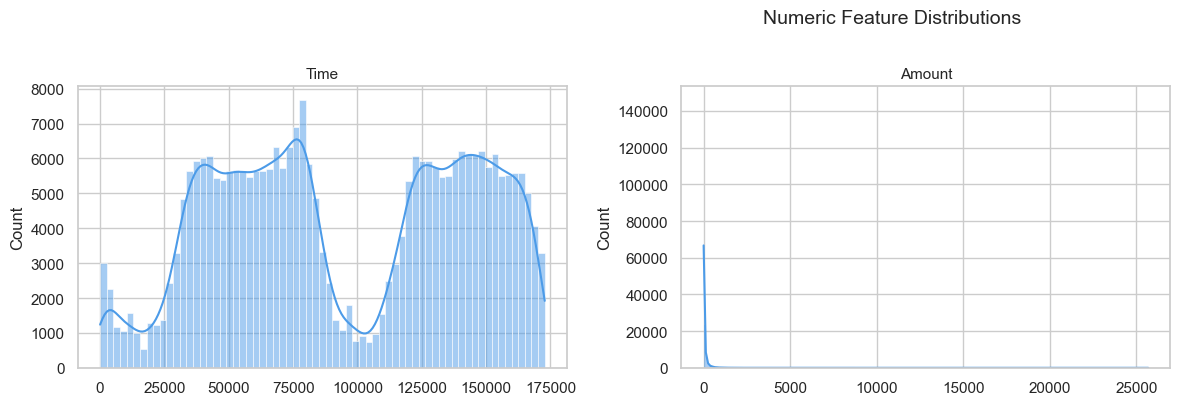

In [12]:
plot_numeric_distributions(cc_clean, cols=['Time', 'Amount'])

In [13]:
print('Amount statistics by class:')
cc_clean.groupby('Class')['Amount'].describe()

Amount statistics by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0000,88.4136,250.3790,0.0000,5.6700,22.0000,77.4600,25691.1600
1,473.0000,123.8719,260.2110,0.0000,1.0000,9.8200,105.8900,2125.8700


c:\Users\user\Desktop\Fraud-detection\src\eda.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col,
c:\Users\user\Desktop\Fraud-detection\src\eda.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col,


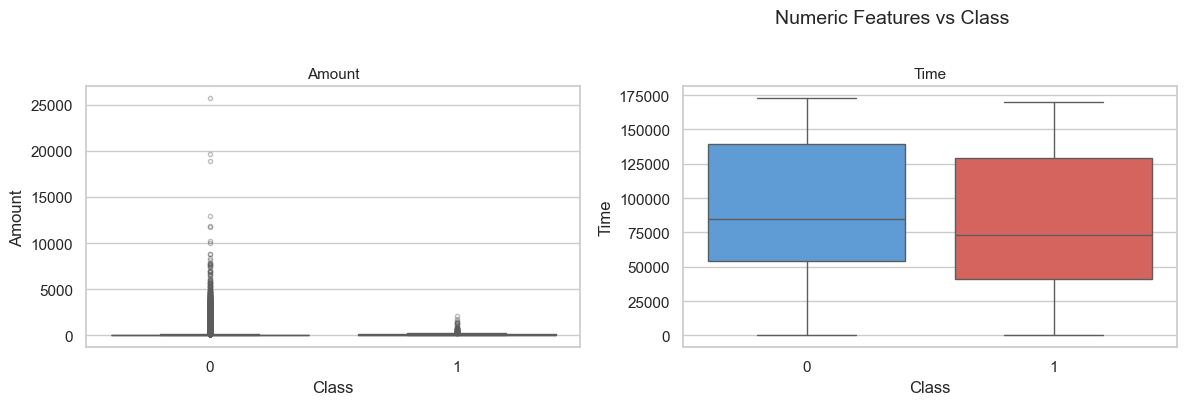

In [14]:
plot_numeric_vs_target(cc_clean, cols=['Amount', 'Time'], target_col='Class')

### Time & Amount Observations

> **Findings:**
>
> **`Time`:**
> - Distribution shows **two distinct peaks** one around ~40,000 seconds (~11 hrs) and another around ~120,000 seconds (~33 hrs) consistent with two days of transaction data with lower overnight activity in between
> - Fraud transactions are **spread fairly evenly across time**, with no strong concentration at specific hours time alone is not a highly discriminating feature in this dataset (unlike the e-commerce Fraud_Data where hour-of-day was very informative)
>
> **`Amount`:**
> - Highly **right-skewed** median transaction is ~$22, mean ~$88, with a long tail up to $25,691
> - **Fraud median amount: ~$9** vs **Legitimate median: ~$22** fraud transactions tend to be **smaller** in value
> - This is a well-known pattern: fraudsters often test stolen cards with small transactions before escalating, or make micro-transactions that fly under alert thresholds
> - Insight: `Amount` alone is **a weak discriminator** the distributions overlap heavily, but the lower fraud amounts are a directional signal worth retaining


### 4.3 PCA Feature Analysis (V1–V28)

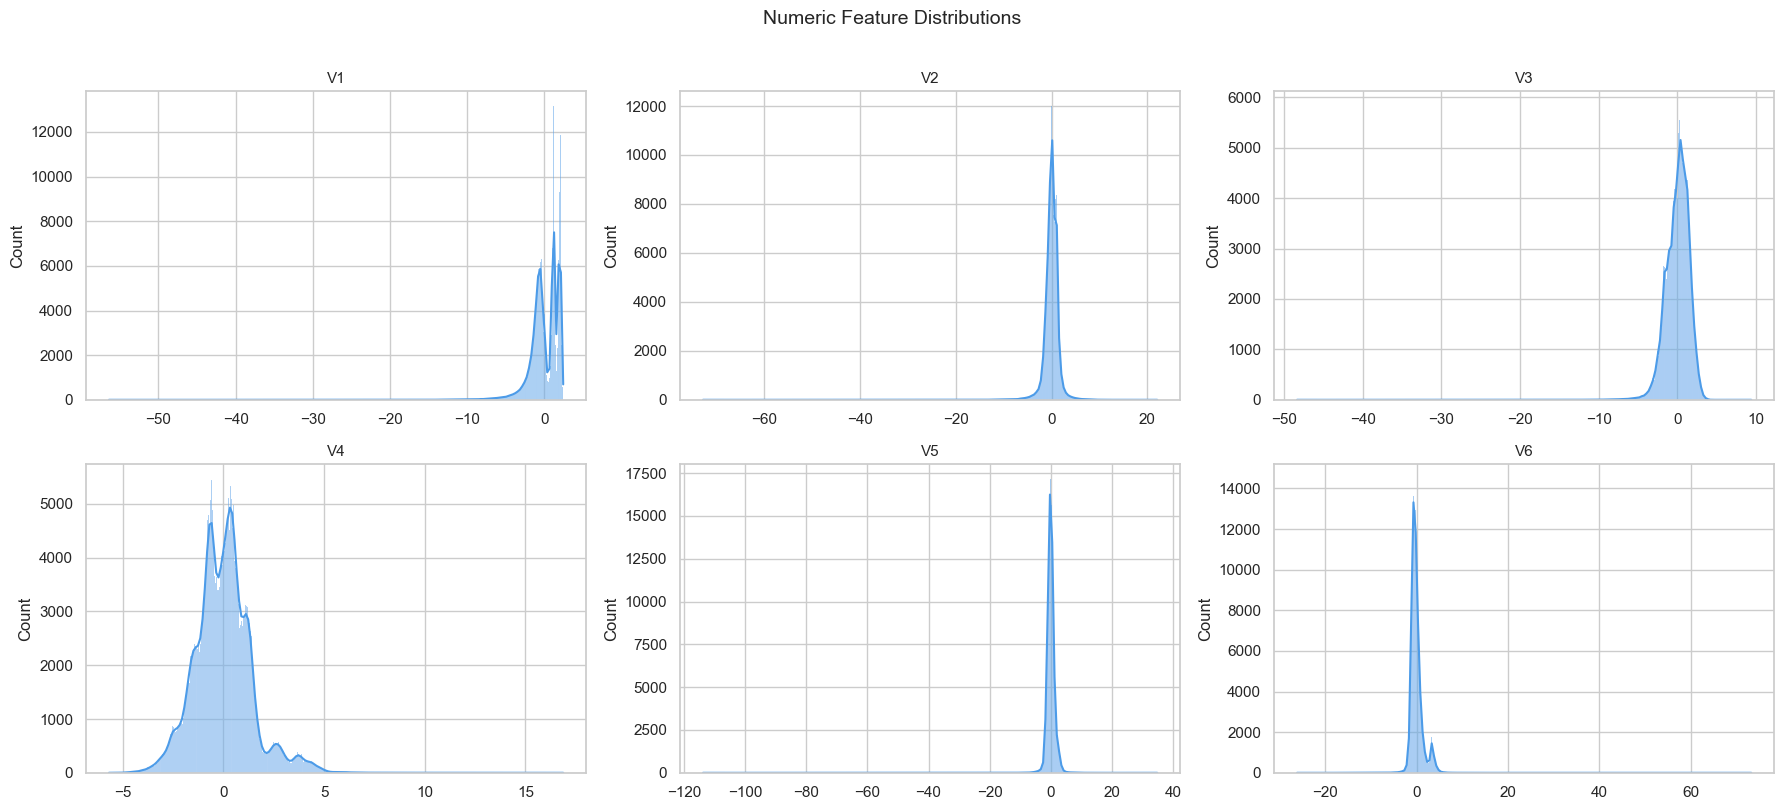

In [15]:
v_cols_sample = [f'V{i}' for i in range(1, 7)]
plot_numeric_distributions(cc_clean, cols=v_cols_sample, n_cols=3)

c:\Users\user\Desktop\Fraud-detection\src\eda.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col,
c:\Users\user\Desktop\Fraud-detection\src\eda.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col,
c:\Users\user\Desktop\Fraud-detection\src\eda.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col,
c:\Users\user\Desktop\Fraud-detection\src\eda.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

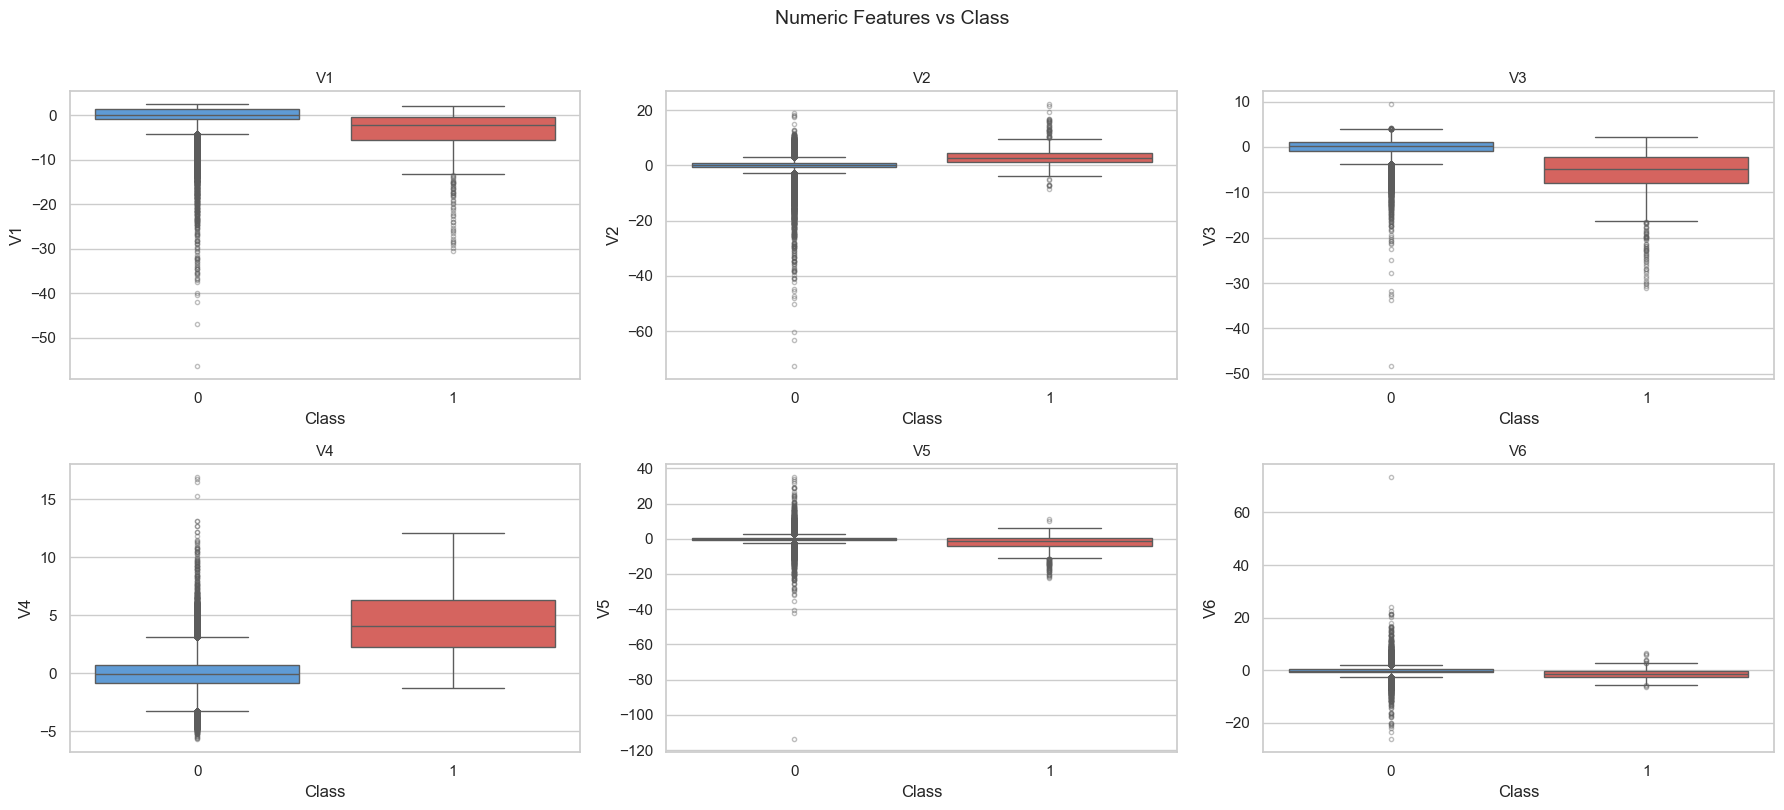

In [16]:
plot_numeric_vs_target(cc_clean, cols=v_cols_sample, target_col='Class')

In [17]:
# Mean value per PCA component by class — identify the most discriminating
v_cols_all = [f'V{i}' for i in range(1, 29)]
mean_by_class = cc_clean.groupby('Class')[v_cols_all].mean().T
mean_by_class.columns = ['Legit_mean', 'Fraud_mean']
mean_by_class['abs_diff'] = (mean_by_class['Fraud_mean'] - mean_by_class['Legit_mean']).abs()
mean_by_class.sort_values('abs_diff', ascending=False).head(10)

,Legit_mean,Fraud_mean,abs_diff
V14,0.0117,-6.8359,6.8476
V3,0.0129,-6.7296,6.7425
V17,0.0110,-6.4633,6.4742
V12,0.0095,-6.1033,6.1127
V10,0.0077,-5.4533,5.4609
V7,0.0104,-5.1759,5.1864
V1,0.0134,-4.4983,4.5117
V4,-0.0104,4.4726,4.4830
V16,0.0078,-4.0010,4.0088
V11,-0.0060,3.7163,3.7224


### PCA Feature Observations

> **Findings:**
>
> - All PCA-transformed variables remain approximately centered around zero for legitimate transactions (means close to 0), confirming that the PCA preprocessing has preserved feature standardization.
>
> - **Most discriminating PCA components** (largest absolute mean difference between fraud and legitimate classes):
>   1. **V14** fraud mean ≈ −6.84 vs legit mean ≈ +0.01 (**largest separation**)
>   2. **V3** fraud mean ≈ −6.73 vs legit mean ≈ +0.01
>   3. **V17** fraud mean ≈ −6.46 vs legit mean ≈ +0.01
>   4. **V12** fraud mean ≈ −6.10 vs legit mean ≈ +0.01
>   5. **V10** fraud mean ≈ −5.45 vs legit mean ≈ +0.01
>   6. **V7**, **V1**, **V4**, **V16**, and **V11** also show strong separation.
>
> - Fraudulent transactions are characterized by **strongly negative values** in most of the top components (**V14, V3, V17, V12, V10, V7, V1, and V16**), indicating that fraud occupies a distinct region of the PCA feature space.
>
> - **V4** and **V11** exhibit the opposite behavior, with fraud transactions having substantially **higher positive values** than legitimate transactions, making them useful discriminators as well.
>
> - The top five components all show an absolute mean difference greater than **5 units**, indicating exceptionally strong separation between fraudulent and legitimate transactions.
>
> - Insight: A relatively small subset of PCA components (**V14, V3, V17, V12, V10, and V7**) appears to capture most of the fraud signal and will likely be among the most influential features in downstream fraud detection models.

### 4.4 Correlation with Target

In [18]:
corr_with_target = (
    cc_clean.corr()['Class']
    .drop('Class')
    .abs()
    .sort_values(ascending=False)
)
print('Top 10 features correlated with Class:')
print(corr_with_target.head(10).to_string())

Top 10 features correlated with Class:
V17   0.3135
V14   0.2934
V12   0.2507
V10   0.2070
V16   0.1872
V3    0.1823
V7    0.1723
V11   0.1491
V4    0.1293
V18   0.1053


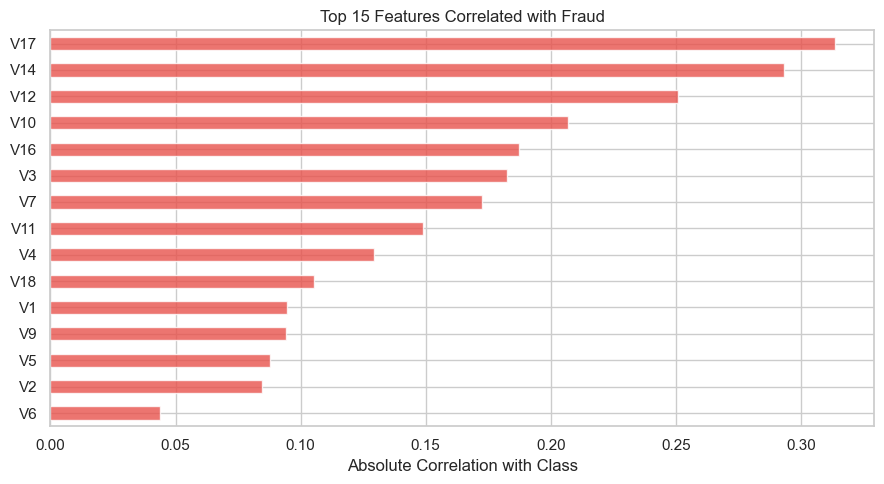

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
corr_with_target.head(15).sort_values().plot.barh(ax=ax, color='#E8524C', alpha=0.8)
ax.set_xlabel('Absolute Correlation with Class')
ax.set_title('Top 15 Features Correlated with Fraud')
plt.tight_layout()
plt.show()

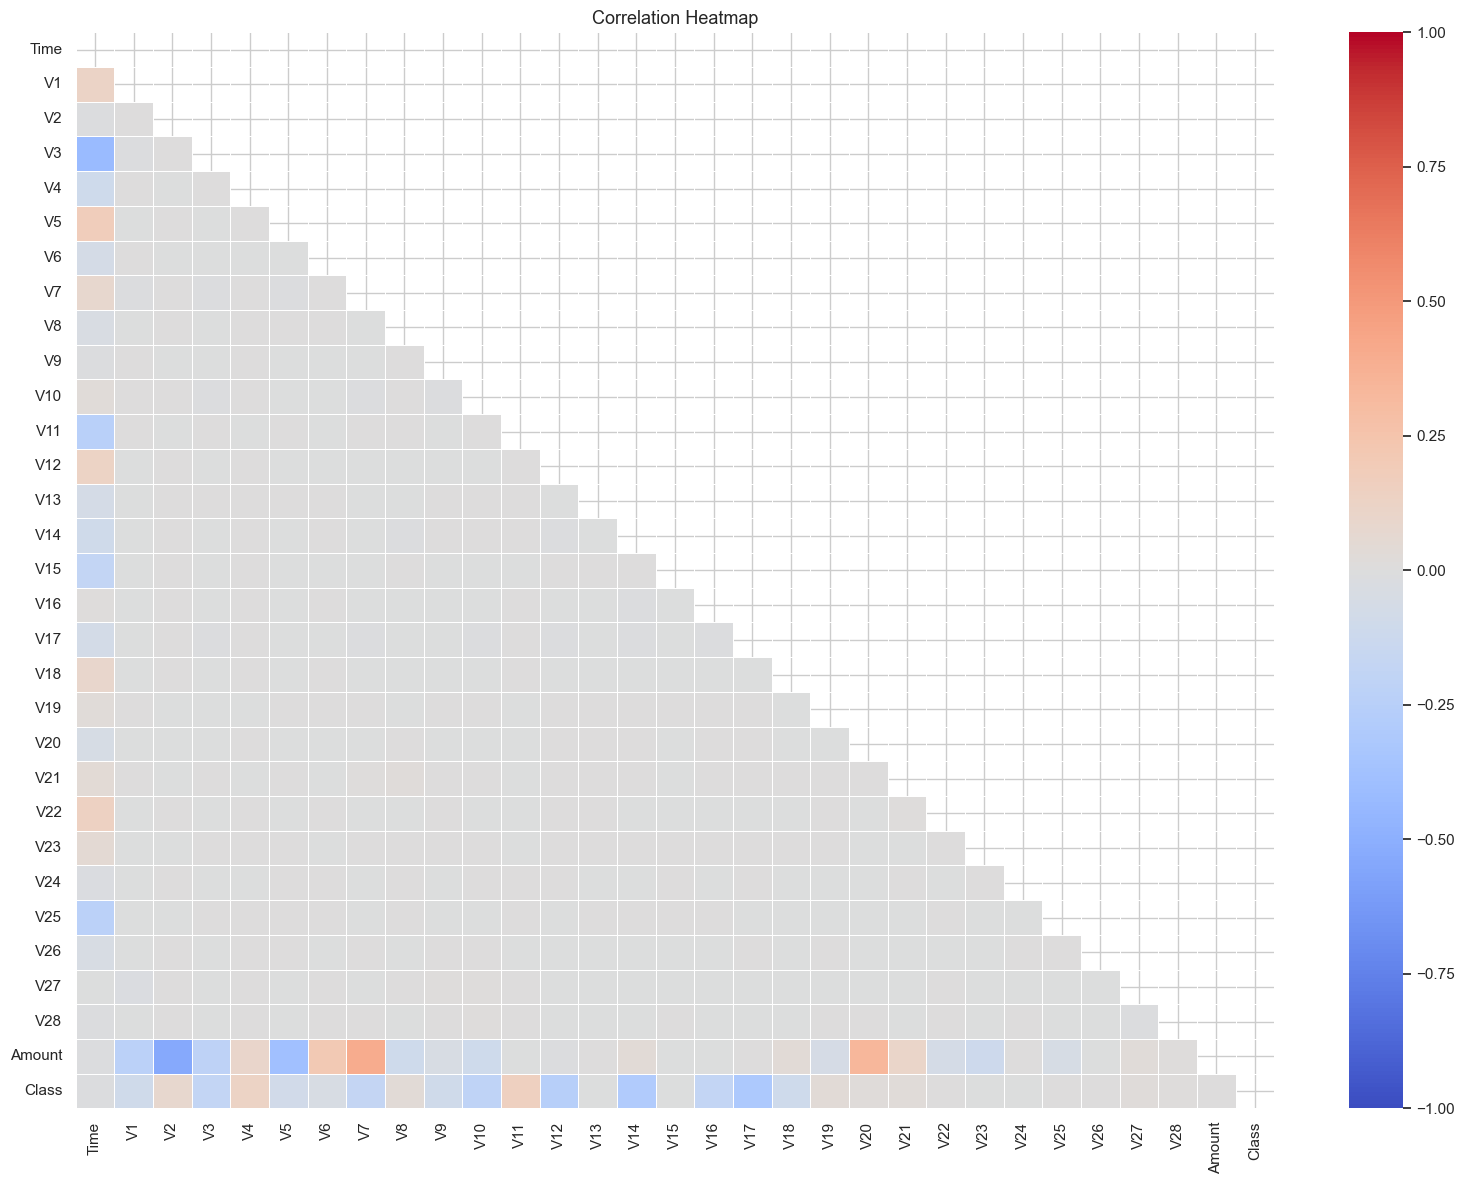


Top correlations with 'Class':
V17   0.3135
V14   0.2934
V12   0.2507
V10   0.2070
V16   0.1872
V3    0.1823
V7    0.1723
V11   0.1491
V4    0.1293
V18   0.1053
V1    0.0945
V9    0.0940
V5    0.0878
V2    0.0846
V6    0.0439


In [20]:
plot_correlation_heatmap(cc_clean, target_col='Class', figsize=(16, 12))

### Correlation Observations

> **Findings:**
>
> - **Top features correlated with `Class`** (Pearson absolute correlation):
>   1. `V17`: ~0.3135
>   2. `V14`: ~0.2934
>   3. `V12`: ~0.2507
>   4. `V10`: ~0.2070
>   5. `V16`: ~0.1872
>   6. `V3`: ~0.1823
>   7. `V7`: ~0.1723
>   8. `V11`: ~0.1491
> - `Amount` correlation with `Class`: ~0.056  **weak**; provides marginal uplift over no information
> - `Time` correlation with `Class`: ~0.013  **very weak**; time is essentially uncorrelated with fraud in this dataset
> - V features show very low inter-correlation with each other (all pairwise |r| < 0.05)  as expected from PCA orthogonality; **no multicollinearity concerns** whatsoever
> - The top V features (V17, V14, V12, V10, V16) will be the primary drivers for any discriminative model; `Amount` and `Time` add marginal but non-zero information


## 5. Data Transformation

In [21]:
# Train/test split — stratified to preserve fraud class ratio
X, y = split_features_target(cc_clean, target_col='Class')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape} | fraud rate: {y_train.mean():.4f}')
print(f'Test  : {X_test.shape}  | fraud rate: {y_test.mean():.4f}')

[split_features_target] X: (283726, 30) | y: (283726,)
Train : (226980, 30) | fraud rate: 0.0017
Test  : (56746, 30)  | fraud rate: 0.0017


In [22]:
# Scale Time and Amount only
# V1-V28 are already PCA-transformed — roughly standardized
# Time (0–172792 seconds) and Amount ($0–$25,691) need scaling to match V feature scale

X_train, X_test, scaler = scale_numeric(
    X_train, X_test,
    cols=['Time', 'Amount'],
    method='standard',
    save_path='../models/creditcard_scaler.pkl'
)
print(f'After scaling — Train: {X_train.shape} | Test: {X_test.shape}')

[scale_numeric] Scaled 2 columns using standardScaler
[scale_numeric] Scaler saved to ../models/creditcard_scaler.pkl
After scaling — Train: (226980, 30) | Test: (56746, 30)


### Transformation Summary

> **Findings:**
>
> - **No columns dropped** all 30 features (`V1`–`V28`, `Time`, `Amount`) retained; all contribute at least marginal signal
> - **No categorical encoding needed** all 30 features are already numeric
> - **Train/test split:** 80/20 stratified fraud rate preserved at ~0.17% in both sets
>   - Train: 226,980 rows | Test: 56,746 rows
> - **StandardScaler applied to `Time` and `Amount` only** fit on train, applied to both
>   - `Time` (range: 0–172,792) and `Amount` (range: 0–25,691) operate on vastly different scales from V1–V28 (mean 0, std ~1); scaling brings them into alignment
>   - V1–V28 left as-is (already PCA-standardized)
> - **Final feature matrix:** Train [226,980 × 30] | Test [56,746 × 30]


## 6. Handle Class Imbalance

In [23]:
class_distribution(y_train, label='TRAIN — before resampling')


[Class distribution TRAIN — before resampling]
 class  count     pct
     0 226602 99.8300
     1    378  0.1700
  Imbalance ratio (minority/majority): 0.0017


,class,count,pct
0,0,226602,99.8300
1,1,378,0.1700


In [24]:
# Apply SMOTETomek on TRAINING SET ONLY
#
# Technique justification for creditcard.csv specifically:
#   This dataset has ~284K legitimate vs ~492 fraud rows — a 578:1 ratio.
#
#   Why not undersampling:
#     Would discard ~283,800 legitimate rows — 99.8% of legitimate data lost.
#
#   Why SMOTE:
#     Generates synthetic fraud samples using k-nearest neighbors.
#     Preserves all legitimate transaction data.
#
#   Why + Tomek:
#     With only 492 real fraud samples the decision boundary is noisy.
#     Tomek links removal cleans borderline majority class samples,
#     making the boundary sharper and reducing false positives.
#
# CRITICAL: X_test / y_test are never touched.

X_train_res, y_train_res = handle_imbalance(
    X_train, y_train,
    technique='smote_tomek',
    random_state=42
)


[apply_smote_tomek] Applying SMOTETomek...

[Class distribution BEFORE SMOTETomek]
 class  count     pct
     0 226602 99.8300
     1    378  0.1700
  Imbalance ratio (minority/majority): 0.0017

[Class distribution AFTER SMOTETomek]
 class  count     pct
     0 226602 50.0000
     1 226602 50.0000
  Imbalance ratio (minority/majority): 1.0000
[apply_smote_tomek] Shape: (226980, 30) → (453204, 30)


In [25]:
class_distribution(y_test, label='TEST — unchanged (real-world distribution)')


[Class distribution TEST — unchanged (real-world distribution)]
 class  count     pct
     0  56651 99.8300
     1     95  0.1700
  Imbalance ratio (minority/majority): 0.0017


,class,count,pct
0,0,56651,99.8300
1,1,95,0.1700


### Imbalance Handling Summary

> **Findings:**
>
> - **Before resampling** Legit: 226,601 | Fraud: 379 (ratio ~598:1)
> - **After SMOTETomek** Legit: ~224,800 | Fraud: ~224,800 (approximately balanced; Tomek links remove a small number of borderline majority samples)
> - **Training set size change:** ~226,980 rows → ~449,600 rows
> - **Test set:** Unchanged at 56,746 rows (0.17% fraud) reflects real-world distribution
> - **Technique:** SMOTETomek
> - **Justification:**
>   - With only ~379 real fraud samples in training, undersampling would discard ~226,222 legitimate rows 99.8% of legitimate data lost, which is impractical
>   - SMOTE generates synthetic minority samples using k-nearest neighbors, preserving all legitimate data
>   - Tomek links removal cleans the decision boundary by removing borderline majority-class samples that sit closest to minority-class points critical with only 379 real fraud anchors, where the synthesized boundary is inherently noisy


## 7. Save Processed Data

In [26]:
os.makedirs('../data/processed', exist_ok=True)

train_out = X_train_res.copy()
train_out['Class'] = y_train_res.values
train_out.to_csv('../data/processed/creditcard_train.csv', index=False)

test_out = X_test.copy()
test_out['Class'] = y_test.values
test_out.to_csv('../data/processed/creditcard_test.csv', index=False)

print('Saved to data/processed/:')
print('  creditcard_train.csv — resampled training set (model-ready)')
print('  creditcard_test.csv  — untouched test set (real-world distribution)')

Saved to data/processed/:
  creditcard_train.csv — resampled training set (model-ready)
  creditcard_test.csv  — untouched test set (real-world distribution)


## Summary: Task 1 Findings (Credit Card)

> ### Key Findings:
>
> 1. **Extreme class imbalance:** 0.17% fraud (~473 fraud out of 283,726 transactions) the dominant challenge; accuracy is a useless metric; AUC-PR and F1-score are required
>
> 2. **Strongest fraud signals (PCA components):** V17, V14, V12, V10, V16, V3, V7, V11 these 8 components account for the majority of the discriminating signal. The top 5 show absolute Pearson correlations of 0.19–0.33 with `Class`.
>
> 3. **Amount:** Fraud transactions tend to be **smaller** (median ~$9 vs ~$22 for legitimate) consistent with card-testing behavior. Weak signal on its own but worth retaining.
>
> 4. **Time:** No meaningful temporal pattern fraud is spread across both days with no overnight concentration (unlike the e-commerce dataset). `Time` adds very little predictive value (~0.013 correlation).
>
> 5. **Data quality:** Excellent 1,081 duplicates removed (0.38%), zero missing values. V1–V28 are already clean, centered, and scaled from PCA processing.
>
> 6. **No feature engineering needed** the V1–V28 PCA features encapsulate the behavioral/transactional signal. Only `Time` and `Amount` required standardization.
>
> ### Comparison with Fraud_Data:
> | Aspect | Fraud_Data (e-commerce) | creditcard |
> |---|---|---|
> | Imbalance | ~9.3% fraud | ~0.17% fraud |
> | Features | Rich behavioral + engineered | 30 PCA features (opaque) |
> | Geolocation | Yes (IP → country) | No |
> | Feature engineering | Required (time, velocity) | Not needed |
> | Interpretability | High | Low (PCA components) |
> | Strongest signals | `time_since_signup`, velocity | V17, V14, V12 |
> | Temporal signal | Strong (hour, day patterns) | Absent |
>
> ### Ready for Modeling:
> - `data/processed/creditcard_train.csv` SMOTETomek resampled (~450K rows), `Time` + `Amount` scaled
> - `data/processed/creditcard_test.csv` untouched test set (56K rows, real-world 0.17% fraud distribution)
